<a href="https://colab.research.google.com/github/berevai/METODOS-NUMERICOS/blob/main/M%C3%A9todos%20Bisecci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Método de bisección**

Para resolver ecuaciones no lineales hay varios métodos muy útiles:
* Métodos Cerrados (o de intervalo)
* Métodos Abiertos
* Métodos Especiales para polinomios.

En este ejercicio utilizaremos el primer método viesto en clase: **El Método Cerrado de Bisección**.

Por ser un método cerrado requiere de un intervalo $[a, b]$ donde la función cambia de signo ($f(a) \cdot f(b) < 0$ y garantizan la convergencia si la función es continua.

Pero específicamente el **Método de Bisección** hace lo siguiente:
Sea $f \in C[a,b]$, con $f(a)$ y $f(b)$ de signos opuestos. Por el *teorema del valor intermedio*, existe p $\in (a,b)$, tal que $f(p)=0$. Es decir, $f$ tiene una raíz/solución en $(a,b)$.
Es decir, divide el intervalo a la mitad iterativamente. Es de convergencia lenta (lineal).

In [6]:
from math import *
import numpy as np
import matplotlib.pyplot as plt

Queremos resolver la ecuación $x^3+4x^2-10=0$ en el intervalo $[1,2]$

Para aplicar el **método de bisección** verificamos qué la función $f(x)$ evaluada en los extremos tiene signos opuestos

Evaluando la función en 1 y 2

In [7]:
f2=f(2)
print(f"La función evaluada en 1 es: {f2}")

La función evaluada en 1 es: 14.0


In [8]:
f1=f(1)
print(f"La función evaluada en 1 es: {f1}")

La función evaluada en 1 es: -5.0


Por el *Teorema de valor intermedio* hay una raíz en el intervalo $[1,2]$ ya que la función es continua ya que es un polinomio. Definamos nuestro polinomio:

In [9]:
def f(x):
	return x**3 + 4*x**2 - 10.0

Graficado f(x)

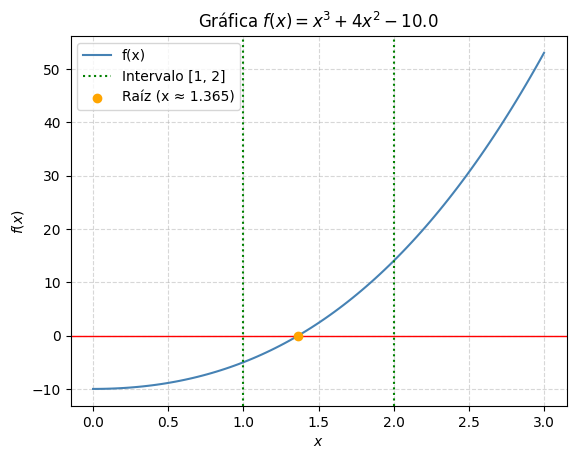

In [24]:
x = np.linspace(0, 3, 100)

# Graficamos la función (agregamos label para la leyenda)
plt.plot(x, f(x), label="f(x)", color="steelblue")

plt.title("Gráfica $f(x)= x^3 + 4x^2 - 10.0$")
plt.xlabel("$x$")
plt.ylabel("$f(x)$")

# Líneas verticales punteadas para marcar el intervalo [1, 2]
plt.axvline(x=1, color="green", linestyle=":", label="Intervalo [1, 2]")
plt.axvline(x=2, color="green", linestyle=":")

# Punto de la raíz
plt.scatter(1.365, 0, color="orange", zorder=5, label="Raíz (x ≈ 1.365)")

# Línea horizontal en y=0
plt.axhline(y=0, color="red", linewidth=1)

# Rejilla y mostramos la leyenda
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.show()


In [25]:
# Ingreso de datos de entrada para los diferentes métodos a trabajar
a=1
b=2
# Guarda valores iniciales
a0=a
b0=b
tol=0.000001 # Error
nmax=100 # Número máx de iteraciones
error=100 # Valor inicial del error
niter=0 # Contador de iteraciones


### Método de Bisección

# Evaluo primer valor medio
m = a + (b - a)/2

# Evaluacion de la función en los puntos a, b y m
fa = f(a)
fb = f(b)
fm = f(m)

print("# iter\t\t a \t\t f(a) \t\t b \t\t f(b) \t\t m \t\t f(m) \t\t error")
print("{0} \t\t {1:6.4f} \t {2:6.4f} \t {3:6.4f} \t {4:6.4f} \t {5:6.4f} \t {6:6.4f} \t {7:6.4f}".format(niter, a0, fa, b0, fb, m, fm, error ))

# Ciclo iterativo
while error > tol and niter < nmax: # Criterios de terminación
  m = a + (b - a) / 2
  if np.sign(fa) == np.sign(fm):# Esta función devuelve signo
      a = m
      fa = f(a)
  else:
      b = m
      fb = f(b)

  m = a + (b - a)/2
  fm = f(m)
  error = abs(b - a)
  niter += 1
  print("{0} \t\t {1:6.6f} \t {2:6.6f} \t {3:6.6f} \t {4:6.6f} \t {5:6.6f} \t {6:6.6f} \t {7:6.6f}".format(niter, a, fa, b, fb, m, fm, error ))

print("La raíz de la función dada en el intervalo [{0:6.4f},{1:6.4f}] es {2:6.7f}".format(a0,b0,m))

# iter		 a 		 f(a) 		 b 		 f(b) 		 m 		 f(m) 		 error
0 		 1.0000 	 -5.0000 	 2.0000 	 14.0000 	 1.5000 	 2.3750 	 100.0000
1 		 1.000000 	 -5.000000 	 1.500000 	 2.375000 	 1.250000 	 -1.796875 	 0.500000
2 		 1.250000 	 -1.796875 	 1.500000 	 2.375000 	 1.375000 	 0.162109 	 0.250000
3 		 1.250000 	 -1.796875 	 1.375000 	 0.162109 	 1.312500 	 -0.848389 	 0.125000
4 		 1.312500 	 -0.848389 	 1.375000 	 0.162109 	 1.343750 	 -0.350983 	 0.062500
5 		 1.343750 	 -0.350983 	 1.375000 	 0.162109 	 1.359375 	 -0.096409 	 0.031250
6 		 1.359375 	 -0.096409 	 1.375000 	 0.162109 	 1.367188 	 0.032356 	 0.015625
7 		 1.359375 	 -0.096409 	 1.367188 	 0.032356 	 1.363281 	 -0.032150 	 0.007812
8 		 1.363281 	 -0.032150 	 1.367188 	 0.032356 	 1.365234 	 0.000072 	 0.003906
9 		 1.363281 	 -0.032150 	 1.365234 	 0.000072 	 1.364258 	 -0.016047 	 0.001953
10 		 1.364258 	 -0.016047 	 1.365234 	 0.000072 	 1.364746 	 -0.007989 	 0.000977
11 		 1.364746 	 -0.007989 	 1.365234 	 0.000072 	 1.36499

¡Y con esto terminamos! Podemos concluir que nuestra aproximación es lo suficientemente buena como para ser correcta dentro de un margen de $10^{-4}$. El valor real de la raíz p, con nueve decimales, es:

$p \approx 1.365230013$

Observemos que al comparar las iteraciones, $p_9$ quedó más cerca de $p$ que $p_{13}$. A primera vista, uno podría pensar que esto es verdad solo porque $|f(p_9)| < |f(p_{13})|$. Pero no podemos confiarnos en ello. A menos que ya conozcamos la respuesta verdadera, el hecho de que el valor absoluto de la función sea más pequeño no nos garantiza que estemos más cerca de la raíz.

Por lo tanto el residuo $|f(x)|$ nos da pistas de qué tan bien vamos, pero no es lo mismo que el error real $|x - p|$.





*Rubio Ortega Berenice c:*